In [3]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import os
import re
import sys
import matplotlib.pyplot as plt
import random
import pickle
from Functions.TedaGraphs import *
from Functions.Graphs import *
from scipy.interpolate import interp1d

def get_interpolation_func(x_array, y_array, kind='slinear'):
    f = interp1d(x_array, y_array, kind=kind, fill_value="extrapolate")
    return f
newColumns = ['time_s', 'control_V_mA', 'Ecell_V', 'I_mA', 'Q_discharge_mA_h',
           'Q_charge_mA_h', 'control_V', 'control_mA', 'cycle_number'] 

In [ ]:
File = 'CY25-05_1-#1.csv'
path = f'Dataset/Dataset_1_NCA_battery/Dataset_1_NCA_battery/{File}'
out = f'Dataset/Dataset_1_NCA_battery_R01/{File[:-4]}'
os.makedirs(out,exist_ok=True)

df = pd.read_csv(path)
T = df.iloc[:,0].values
v= df.iloc[:,2].values
I = df.iloc[:,3].values
tvec = np.array([])
iref = np.array([])
for j,t in enumerate(T):
    if j >0:
        if I[j-1]==0 and I[j]>I[j-1]:
            tvec = np.append(tvec,t)
            iref = np.append(iref,j)


for i in range(len(iref)):
    if i == 0: 
        df2 = df[0:int(iref[i])]
    else:
        df2 = df[int(iref[i-1]):int(iref[i])]
    out_file = os.path.join(out,f'{i+1}.csv')
    df2.columns = newColumns
    df2.to_csv(out_file,index=False)

In [ ]:
File = 'CY25-05_1-#1.csv'
path = f'Dataset/Dataset_1_NCA_battery/Dataset_1_NCA_battery/{File}'
out = f'Dataset/Dataset_1_NCA_battery_R01/{File[:-4]}'
os.makedirs(out,exist_ok=True)

df = pd.read_csv(path)
df.columns = newColumns
smpls = np.unique(df.iloc[:,-1].values)
fltr = df[df['cycle_number'] == 25]


In [46]:
len(btr)

16

In [ ]:
dir = r'Dataset/Dataset_1_NCA_battery/Dataset_1_NCA_battery'
btrs = os.listdir(dir)
btrs.sort(key=lambda x: int(re.search(r'\d+', x).group()))

for btr in btrs:
    if btr.startswith('CY25-05_1'):
        out = f'Dataset/Dataset_1_NCA_battery_R01/{btr[:-4]}'
        os.makedirs(out,exist_ok=True)
        path = os.path.join(dir,btr)
        print(path)
        df=pd.read_csv(path)
        df.columns = newColumns
        smpls = np.unique(df.iloc[:,-1].values)
        for smpl in smpls:
            df2 = df[df['cycle_number'] == smpl]
            out_file = os.path.join(out,f'{int(smpl)}.csv')
            df2.columns = newColumns
            df2.to_csv(out_file,index=False)
            print(out_file)


In [14]:
df

,time/s,control/V/mA,Ecell/V,<I>/mA,Q discharge/mA.h,Q charge/mA.h,control/V,control/mA,cycle number
0,0.000000e+00,1750.0,3.112509,0.029092,0.0000,0.000971,0.0,1750.0,1.0
1,1.140000e-01,1750.0,3.117627,1748.881650,0.0000,0.056352,0.0,1750.0,1.0
2,5.840000e-01,1750.0,3.122666,1749.435017,0.0000,0.284751,0.0,1750.0,1.0
3,1.286000e+00,1750.0,3.127667,1749.252196,0.0000,0.625855,0.0,1750.0,1.0
4,2.178000e+00,1750.0,3.132706,1749.321183,0.0000,1.059298,0.0,1750.0,1.0
...,...,...,...,...,...,...,...,...,...
122864,2.209312e+06,0.0,3.281483,0.000000,2509.1119,0.000000,0.0,0.0,146.0
122865,2.209432e+06,0.0,3.286759,0.000000,2509.1119,0.000000,0.0,0.0,146.0
122866,2.209552e+06,0.0,3.291444,0.000000,2509.1119,0.000000,0.0,0.0,146.0
122867,2.209672e+06,0.0,3.295814,0.000000,2509.1119,0.000000,0.0,0.0,146.0


In [50]:
dir = r'Dataset\Dataset_1_NCA_battery_R01\CY25-05_1-#01'
samples = os.listdir(dir)
samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
y=np.array([])
for sample in samples[:]:
    path = os.path.join(dir,sample)
    df = pd.read_csv(path)
    y = np.append(y,df.max().values[5]/3500)

In [ ]:
dir = r'Dataset\Dataset_1_NCA_battery_R01'
out = r'Dataset\Dataset_1_NCA_battery_SoH'
os.makedirs(out,exist_ok=True)
btrs = os.listdir(dir)
btrs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
for btr in btrs:
    btr_path = os.path.join(dir,btr)
    samples = os.listdir(os.path.join(dir,btr))
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    y=np.array([])
    for sample in samples[:]:
        path = os.path.join(btr_path,sample)
        df = pd.read_csv(path)
        y = np.append(y,df.max().values[5]/3500)
    df2 = pd.DataFrame()
    df2['soh'] = y
    out_file = os.path.join(out,btr)+'.csv'
    df2.to_csv(out_file,index=False)
            

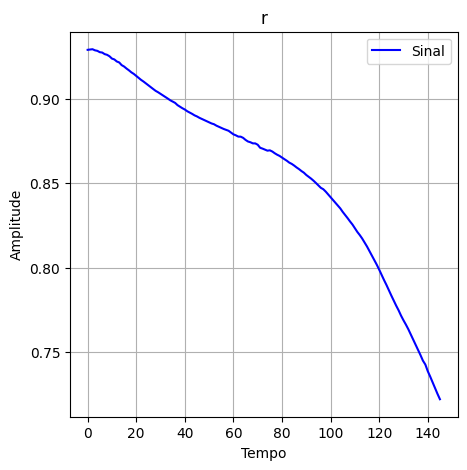

In [85]:
PlotMPL(y=ySeries[0])

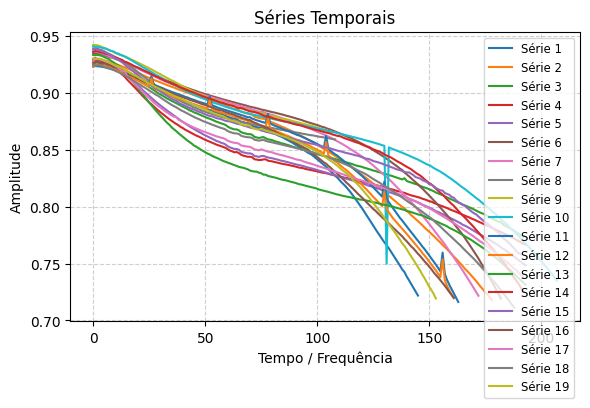

In [86]:
dir = r'Dataset\Dataset_1_NCA_battery_SoH'
btrs = os.listdir(dir)
btrs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
ySeries,names=[],[]
for btr in btrs:
    path = os.path.join(dir,btr)
    df = pd.read_csv(path)
    y = df['soh'].values
    ySeries.append(y)
    names.append(btr[-6:-4])
PlotSeriesPLT(ySeries=ySeries)